# Live Animal Detection

Problem: Developing a product that using Computer Vision and pretrained models to detect animals in videos and live streams

A bounding box will be created around the animal and fine-tuning will allow the model to not only detect but identify the species and display common name, scientific name and confidence percentage

Yolov8n model: YOLOv8 is a computer vision model architecture developed by Ultralytics, the creators of YOLOv5. You can deploy YOLOv8 models on a wide range of devices, including NVIDIA Jetson, NVIDIA GPUs, and macOS systems with Roboflow Inference, an open source Python package for running vision models.


Procedure - 

1. 

In [1]:
!pip install ultralytics yt-dlp opencv-python-headless -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [2]:
!pip install ultralytics pyinaturalist requests -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB" if torch.cuda.is_available() else "")

CUDA available: True
Device: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 8.5 GB


In [ ]:
import cv2
import subprocess
import numpy as np
from ultralytics import YOLO
from IPython.display import display, Image as IPImage
import io

import cv2
import time
import numpy as np
from IPython.display import display, Image as IPImage
from ultralytics import YOLO

from IPython.display import display, Image as IPImage

import subprocess

from google.colab import drive

import json
import os

In [7]:
ANIMAL_CLASS_IDS = {
    14: "bird",
    15: "cat",
    16: "dog",
    17: "horse",
    18: "sheep",
    19: "cow",
    20: "elephant",
    21: "bear",
    22: "zebra",
    23: "giraffe"
}

In [8]:
model = YOLO("yolov8n.pt")
print("Model loaded. Classes we care about:", ANIMAL_CLASS_IDS)

Model loaded. Classes we care about: {14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe'}


In [ ]:

def get_stream_url(youtube_url):
    result = subprocess.run(
        ["yt-dlp", "-f", "best[ext=mp4]/best", "-g", youtube_url],
        capture_output=True, text=True
    )
    stream_url = result.stdout.strip()
    if not stream_url:
        raise ValueError(f"Could not extract stream URL.\nError: {result.stderr}")
    print(" Stream URL extracted successfully")
    print("Preview:", stream_url[:80], "...")
    return stream_url

# Random video here
YOUTUBE_URL = "https://www.youtube.com/watch?v=MiQe9ob9aDc"
stream_url = get_stream_url(YOUTUBE_URL)

 Stream URL extracted successfully
Preview: https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1777033667/ei/ ...


In [11]:

def verify_stream(stream_url):
    cap = cv2.VideoCapture(stream_url)
    if not cap.isOpened():
        raise RuntimeError("OpenCV could not open the stream URL.")

    ret, frame = cap.read()
    if not ret or frame is None:
        raise RuntimeError("Stream opened but could not read a frame.")

    h, w = frame.shape[:2]
    print(f" Stream is live and readable")
    print(f"  Frame size: {w}x{h}")
    print(f"  Frame dtype: {frame.dtype}")
    cap.release()
    return True

verify_stream(stream_url)

 Stream is live and readable
  Frame size: 1920x1080
  Frame dtype: uint8


True

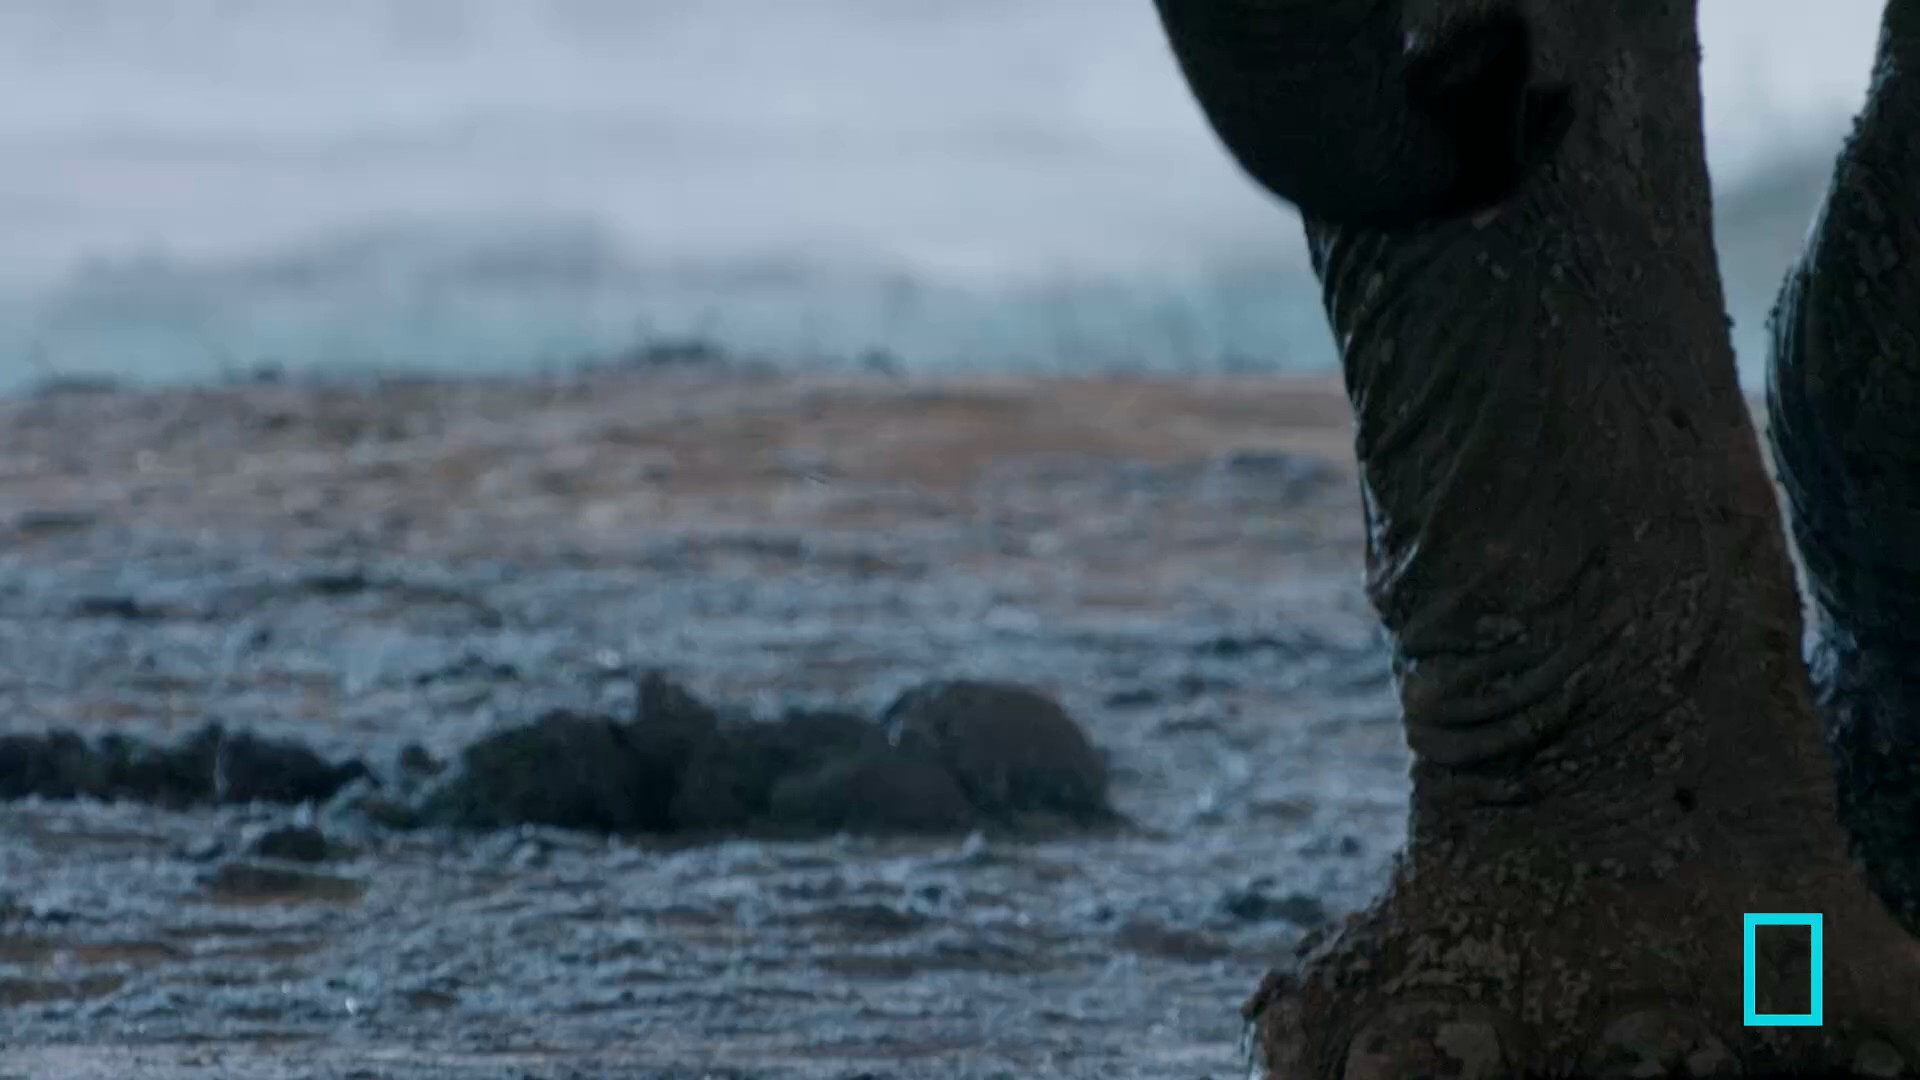

 Frame captured — 1920x1080


In [ ]:


def show_frame(stream_url):
    cap = cv2.VideoCapture(stream_url)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError("Could not read frame.")

    # Convert BGR (OpenCV default) → RGB for display
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Encode as JPEG and display inline in Colab
    _, jpeg = cv2.imencode(".jpg", frame_rgb, [cv2.IMWRITE_JPEG_QUALITY, 90])
    display(IPImage(data=jpeg.tobytes()))
    print(f" Frame captured — {frame.shape[1]}x{frame.shape[0]}")

show_frame(stream_url)

In [14]:


model = YOLO("yolov8n.pt")

ANIMAL_CLASS_IDS = {
    14: "bird", 15: "cat", 16: "dog", 17: "horse",
    18: "sheep", 19: "cow", 20: "elephant", 21: "bear",
    22: "zebra", 23: "giraffe"
}

def detect_frame(frame, conf_threshold=0.3):
    results = model(frame, verbose=False, conf=conf_threshold)[0]

    detections = []
    for box in results.boxes:
        cls_id = int(box.cls[0])
        if cls_id not in ANIMAL_CLASS_IDS:
            continue
        detections.append({
            "class_id": cls_id,
            "class_name": ANIMAL_CLASS_IDS[cls_id],
            "bbox": list(map(int, box.xyxy[0].tolist())),
            "confidence": round(float(box.conf[0]), 3)
        })

    return detections

# grab a fresh frame and run detection
cap = cv2.VideoCapture(stream_url)
ret, frame = cap.read()
cap.release()

detections = detect_frame(frame)
print(f"Detections found: {len(detections)}")
for d in detections:
    print(d)

Detections found: 1
{'class_id': 14, 'class_name': 'bird', 'bbox': [944, 577, 1060, 836], 'confidence': 0.379}


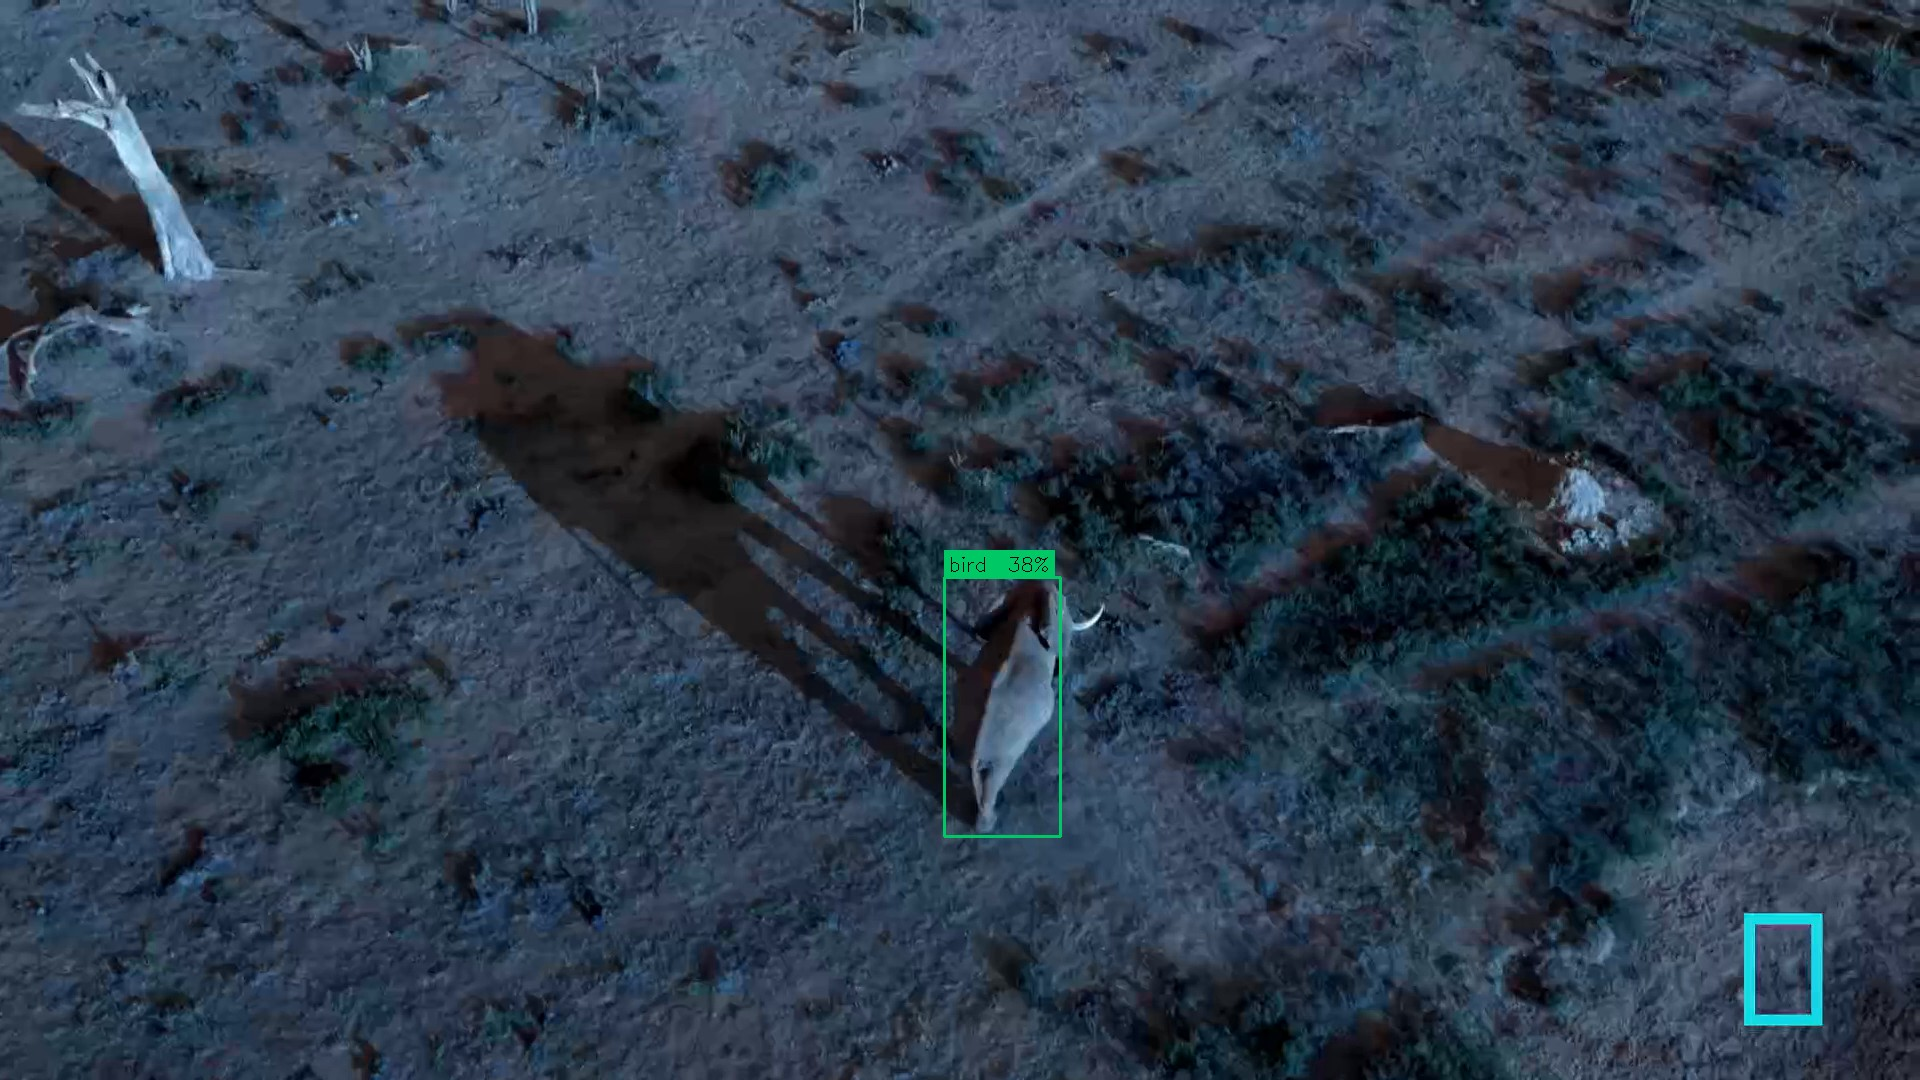

Detection: bird at 38%
Box location: [944, 577, 1060, 836]


In [15]:


def draw_detections(frame, detections):
    output = frame.copy()
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        label = f"{d['class_name']}  {d['confidence']:.0%}"
        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 200, 100), 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 1)
        cv2.rectangle(output, (x1, y1 - th - 12), (x1 + tw + 8, y1), (0, 200, 100), -1)
        cv2.putText(output, label, (x1 + 4, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 1)
    return output

def show(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, jpeg = cv2.imencode(".jpg", frame_rgb, [cv2.IMWRITE_JPEG_QUALITY, 90])
    display(IPImage(data=jpeg.tobytes()))

annotated = draw_detections(frame, detections)
show(annotated)

if len(detections) > 0:
    print(f"Detection: {detections[0]['class_name']} at {detections[0]['confidence']:.0%}")
    print(f"Box location: {detections[0]['bbox']}")
else:
    print("No animals detected in this frame — try grabbing another frame")

Stream Display Configs

In [16]:
#config
CONF_THRESHOLD   = 0.5    # raise from 0.3 — cuts night false positives
EVERY_NTH_FRAME  = 3      # run inference every 3rd frame
MAX_FRAMES       = 300    # stop after this many frames (~30 sec of stream)
BRIGHTNESS_FLOOR = 40     # skip frames darker than this (0-255 scale)

Stream Display helpers

In [17]:
def is_too_dark(frame, threshold=BRIGHTNESS_FLOOR):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray.mean() < threshold

def detect(frame, conf=CONF_THRESHOLD):
    results = model(frame, verbose=False, conf=conf)[0]
    detections = []
    for box in results.boxes:
        cls_id = int(box.cls[0])
        if cls_id not in ANIMAL_CLASS_IDS:
            continue
        detections.append({
            "class_id":   cls_id,
            "class_name": ANIMAL_CLASS_IDS[cls_id],
            "bbox":       list(map(int, box.xyxy[0].tolist())),
            "confidence": round(float(box.conf[0]), 3)
        })
    return detections

More stream display helpers

In [18]:
def draw(frame, detections):
    out = frame.copy()
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        label = f"{d['class_name']}  {d['confidence']:.0%}"
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 200, 100), 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 1)
        cv2.rectangle(out, (x1, y1-th-12), (x1+tw+8, y1), (0, 200, 100), -1)
        cv2.putText(out, label, (x1+4, y1-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 1)
    return out

def add_hud(frame, frame_id, detections, dark_skipped):
    """Heads-up display — stats overlaid on frame"""
    h, w = frame.shape[:2]
    status = f"Frame {frame_id}  |  Animals: {len(detections)}  |  Dark skips: {dark_skipped}"
    cv2.putText(frame, status, (12, h-12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1)
    return frame

def show(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, jpeg = cv2.imencode(".jpg", frame_rgb, [cv2.IMWRITE_JPEG_QUALITY, 85])
    return jpeg.tobytes()

Main stream display loop

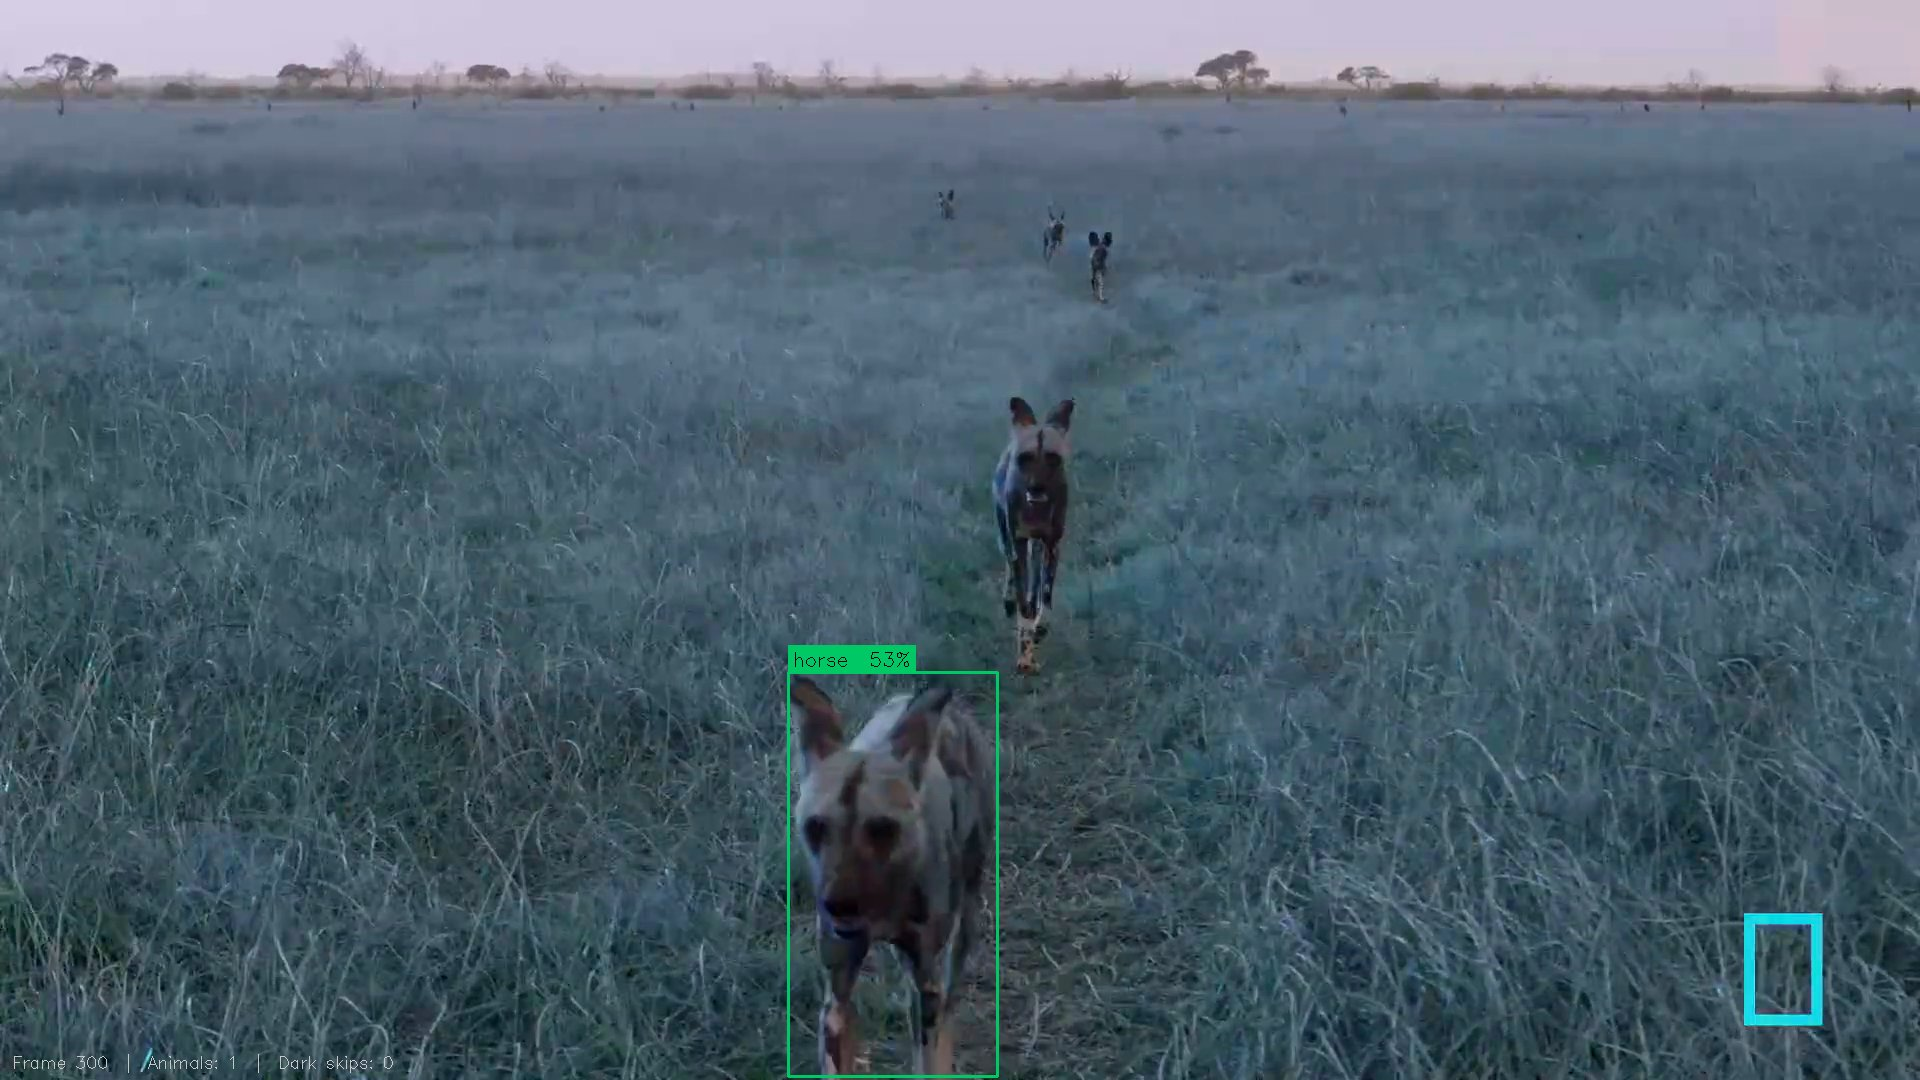

In [21]:
#main stream display loop
def run_live_detection(stream_url):
    cap = cv2.VideoCapture(stream_url)
    if not cap.isOpened():
        raise RuntimeError("Could not open stream — re-run the URL extraction cell.")

    display_handle = display(IPImage(data=b""), display_id=True)

    frame_id    = 0
    dark_skips  = 0
    total_detections = 0
    session_log = []   # stores all detection dicts — your output contract
    t_start     = time.time()

    print("Loop started. Interrupt kernel to stop early (square button).")

    while frame_id < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            print("Stream dropped. Re-extract URL and restart.")
            break

        frame_id += 1

        # skip dark frames
        if is_too_dark(frame):
            dark_skips += 1
            continue

        # only run inference every Nth frame
        if frame_id % EVERY_NTH_FRAME != 0:
            continue

        # detect
        detections = detect(frame)

        # attach frame metadata to each detection
        for d in detections:
            d["frame_id"]  = frame_id
            d["timestamp"] = round(time.time() - t_start, 2)
            session_log.append(d)

        total_detections += len(detections)

        # draw and display
        annotated = draw(frame, detections)
        annotated = add_hud(annotated, frame_id, detections, dark_skips)
        display_handle.update(IPImage(data=show(annotated)))

    cap.release()
    elapsed = round(time.time() - t_start, 1)
    print(f"\n── Session complete ──")
    print(f"Frames processed : {frame_id}")
    print(f"Dark frames skip : {dark_skips}")
    print(f"Total detections : {total_detections}")
    print(f"Elapsed time     : {elapsed}s")
    print(f"Session log size : {len(session_log)} detection events")

    return session_log

session_log = run_live_detection(stream_url)

In [22]:
# see what was detected
print("Detection events this session:")
for event in session_log:
    print(event)

Detection events this session:
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [970, 271, 1115, 903], 'confidence': 0.705, 'frame_id': 3, 'timestamp': 0.05}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [964, 264, 1113, 916], 'confidence': 0.871, 'frame_id': 6, 'timestamp': 0.08}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [957, 260, 1103, 908], 'confidence': 0.768, 'frame_id': 9, 'timestamp': 0.11}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [957, 266, 1101, 909], 'confidence': 0.729, 'frame_id': 12, 'timestamp': 0.15}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [953, 293, 1100, 930], 'confidence': 0.726, 'frame_id': 15, 'timestamp': 0.18}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [950, 269, 1107, 947], 'confidence': 0.851, 'frame_id': 18, 'timestamp': 0.22}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [949, 266, 1108, 980], 'confidence': 0.812, 'frame_id': 24, 'timestamp': 0.29}
{'class_id': 23, 'class_name': 'giraffe', 'bbox': [936, 281, 1109, 99

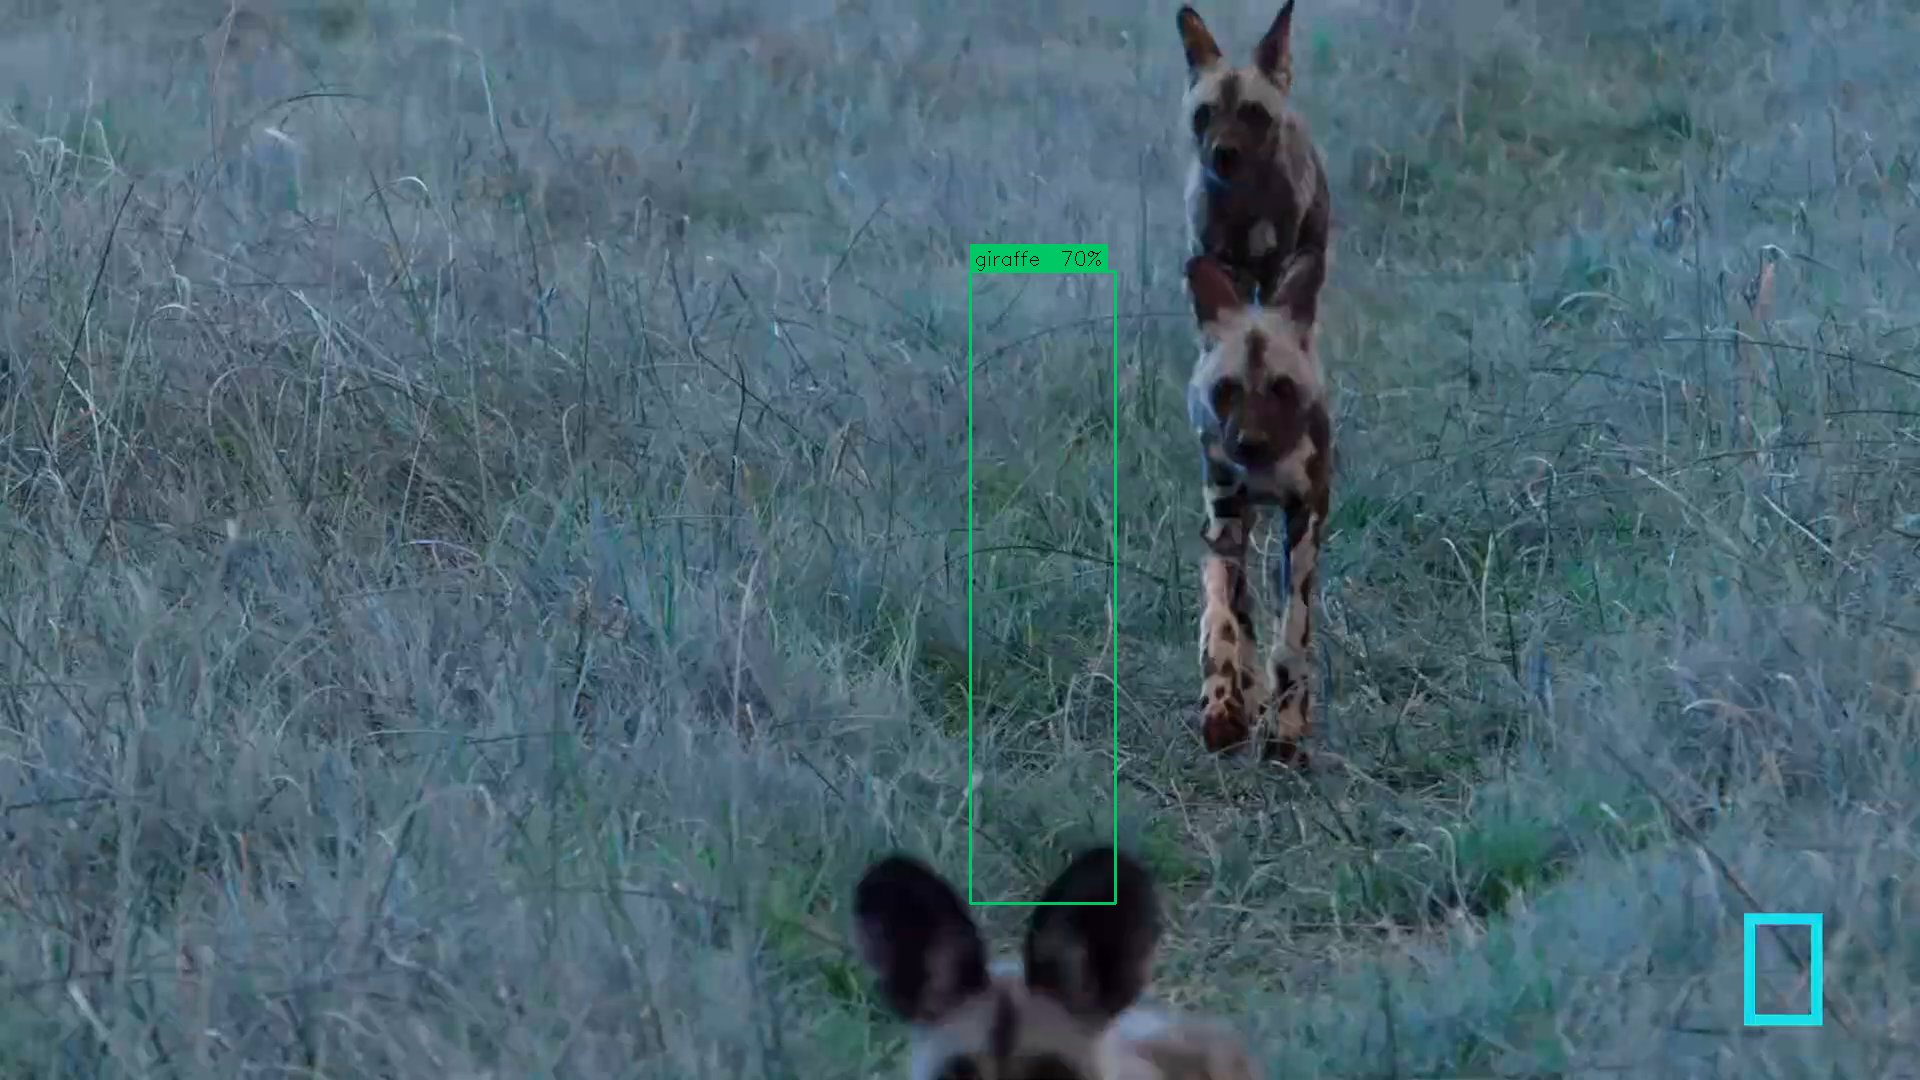

Detected: giraffe at 70% confidence
Box: [970, 271, 1115, 903]


In [23]:
# re-grab a frame at roughly that timestamp and draw the detection
cap = cv2.VideoCapture(stream_url)

target_frame = session_log[0]["frame_id"]

for i in range(target_frame):
    ret, frame = cap.read()

cap.release()

annotated = draw(frame, [session_log[0]])
show_img = show(annotated)

from IPython.display import Image as IPImage, display
display(IPImage(data=show_img))
print(f"Detected: {session_log[0]['class_name']} at {session_log[0]['confidence']:.0%} confidence")
print(f"Box: {session_log[0]['bbox']}")

In [ ]:

drive.mount('/content/drive')

import os
BASE_DIR = "/content/drive/MyDrive/wildlife_detector"
os.makedirs(f"{BASE_DIR}/images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels", exist_ok=True)
os.makedirs(f"{BASE_DIR}/checkpoints", exist_ok=True)
print(f"Working directory: {BASE_DIR}")

ModuleNotFoundError: No module named 'google'

In [ ]:


# annotations JSON only first — no images yet
!wget -q --show-progress \
    https://ml-inat-competition-datasets.s3.amazonaws.com/2021/train_mini.json.tar.gz \
    -O /content/train_mini.json.tar.gz

!tar -xzf /content/train_mini.json.tar.gz -C /content/
print("Annotations extracted")

In [ ]:


# check what files were extracted
print("Files extracted:")
for f in os.listdir("/content"):
    if "train" in f or "val" in f or "json" in f:
        size_mb = os.path.getsize(f"/content/{f}") / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

In [ ]:
# load the annotations
with open("/content/train_mini.json") as f:
    data = json.load(f)

# top level keys
print("\nTop level keys:", list(data.keys()))

# counts
print(f"\nTotal images     : {len(data['images'])}")
print(f"Total annotations: {len(data['annotations'])}")
print(f"Total categories : {len(data['categories'])}")

# peek at one image entry
print("\nSample image entry:")
print(data['images'][0])

# peek at one annotation entry
print("\nSample annotation entry:")
print(data['annotations'][0])

# peek at one category entry
print("\nSample category entry:")
print(data['categories'][0])

In [ ]:
import json
import requests
import cv2
import numpy as np
from collections import defaultdict
from IPython.display import display, Image as IPImage

# ── rebuild all lookup tables ──────────────────────────────
with open("/content/train_mini.json") as f:
    data = json.load(f)

images_by_id = {img["id"]: img for img in data["images"]}
cats_by_id   = {cat["id"]: cat for cat in data["categories"]}

VERTEBRATE_CLASSES = {
    "Mammalia", "Aves", "Reptilia",
    "Amphibia", "Actinopterygii", "Chondrichthyes"
}

vertebrate_cats = {
    cat_id: cat for cat_id, cat in cats_by_id.items()
    if cat.get("kingdom") == "Animalia"
    and cat.get("class") in VERTEBRATE_CLASSES
}

vertebrate_anns = [
    a for a in data["annotations"]
    if a["category_id"] in vertebrate_cats
]

species_ann_counts = defaultdict(int)
for a in vertebrate_anns:
    species_ann_counts[a["category_id"]] += 1

top_cat_ids = {
    cat_id for cat_id, _ in
    sorted(species_ann_counts.items(), key=lambda x: -x[1])[:200]
}

subset_anns = [
    a for a in vertebrate_anns
    if a["category_id"] in top_cat_ids
]

print(f"✓ Rebuilt — {len(subset_anns)} annotations across {len(top_cat_ids)} species")

# ── fetch and display sample images ───────────────────────
def show_inat_image(file_name, title=""):
    url = f"https://ml-inat-competition-datasets.s3.amazonaws.com/2021/{file_name}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code != 200:
            print(f"✗ Could not fetch: {title}")
            return
        img_array = np.frombuffer(r.content, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        cv2.putText(img, title[:60], (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 3)
        cv2.putText(img, title[:60], (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
        _, jpeg = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, 90])
        display(IPImage(data=jpeg.tobytes()))
    except Exception as e:
        print(f"✗ Error fetching {title}: {e}")

TARGET_SPECIES = [
    "Neomonachus schauinslandi",
    "Mola mola",
    "Pseudechis porphyriacus",
    "Phoebastria immutabilis",
    "Sciurus aberti",
    "Coleonyx variegatus",
]

# grab one image per target species
seen = set()
for ann in subset_anns:
    cat = vertebrate_cats[ann["category_id"]]
    if cat["name"] in TARGET_SPECIES and cat["name"] not in seen:
        seen.add(cat["name"])
        img_meta = images_by_id[ann["image_id"]]
        label = f"{cat['name']} | {cat['common_name']} | {cat['class']}"
        print(label)
        show_inat_image(img_meta["file_name"], label)
        print()
    if len(seen) == len(TARGET_SPECIES):
        break

In [ ]:
# count annotations per species
species_ann_counts = defaultdict(int)
for a in vertebrate_anns:
    species_ann_counts[a["category_id"]] += 1

# sort by count — all should have ~50 since it's mini
top_species = sorted(
    species_ann_counts.items(),
    key=lambda x: -x[1]
)[:200]  # take top 200 species to start

top_cat_ids = {cat_id for cat_id, _ in top_species}

print(f"Selected {len(top_species)} species for auto-labeling")
print(f"\nSample species in our training set:")
print(f"{'Scientific Name':40s} {'Common Name':30s} {'Class':20s} {'Images'}")
print("-" * 100)
for cat_id, count in top_species[:20]:
    cat = vertebrate_cats[cat_id]
    print(f"{cat['name']:40s} {cat['common_name']:30s} {cat['class']:20s} {count}")

In [ ]:
import subprocess
import os

# download just the first small chunk of train_mini images
# using AWS CLI partial download isn't easy, so let's use the iNat API instead
# iNat has a public API that returns image URLs for any taxon — no auth needed

import requests
from IPython.display import display, Image as IPImage
import cv2
import numpy as np

TARGET_SPECIES = [
    ("Neomonachus schauinslandi", "Hawaiian Monk Seal"),
    ("Mola mola", "Ocean Sunfish"),
    ("Pseudechis porphyriacus", "Red-bellied Black Snake"),
    ("Phoebastria immutabilis", "Laysan Albatross"),
    ("Sciurus aberti", "Abert's Squirrel"),
    ("Coleonyx variegatus", "Western Banded Gecko"),
]

def fetch_inat_image_url(scientific_name):
    """Hit iNaturalist public API to get a real photo URL"""
    r = requests.get(
        "https://api.inaturalist.org/v1/taxa/autocomplete",
        params={"q": scientific_name, "per_page": 1},
        timeout=10
    )
    results = r.json().get("results", [])
    if not results:
        return None
    taxon = results[0]
    photo = taxon.get("default_photo", {})
    url = photo.get("medium_url") or photo.get("square_url")
    return url

def show_from_url(url, title):
    r = requests.get(url, timeout=10)
    img_array = np.frombuffer(r.content, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        print(f"✗ Could not decode image for {title}")
        return
    # add label
    cv2.putText(img, title[:50], (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 3)
    cv2.putText(img, title[:50], (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
    _, jpeg = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, 90])
    display(IPImage(data=jpeg.tobytes()))

for sci_name, common_name in TARGET_SPECIES:
    print(f"Fetching: {sci_name}")
    url = fetch_inat_image_url(sci_name)
    if url:
        show_from_url(url, f"{sci_name} | {common_name}")
        print()
    else:
        print(f"✗ No image found for {sci_name}\n")

In [ ]:
import requests
import os
import time
import json
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR      = "/content/drive/MyDrive/wildlife_detector"
IMG_DIR       = f"{BASE_DIR}/raw_images"
manifest_path = f"{BASE_DIR}/species_manifest.json"
os.makedirs(IMG_DIR, exist_ok=True)

# ── reload all lookup tables from disk ───────────────────
with open("/content/train_mini.json") as f:
    data = json.load(f)

images_by_id = {img["id"]: img for img in data["images"]}
cats_by_id   = {cat["id"]: cat for cat in data["categories"]}

VERTEBRATE_CLASSES = {
    "Mammalia", "Aves", "Reptilia",
    "Amphibia", "Actinopterygii", "Chondrichthyes"
}

vertebrate_cats = {
    cat_id: cat for cat_id, cat in cats_by_id.items()
    if cat.get("kingdom") == "Animalia"
    and cat.get("class") in VERTEBRATE_CLASSES
}

from collections import defaultdict
vertebrate_anns = [
    a for a in data["annotations"]
    if a["category_id"] in vertebrate_cats
]
species_ann_counts = defaultdict(int)
for a in vertebrate_anns:
    species_ann_counts[a["category_id"]] += 1

top_cat_ids_500 = {
    cat_id for cat_id, _ in
    sorted(species_ann_counts.items(), key=lambda x: -x[1])[:500]
}
SPECIES_TO_DOWNLOAD = [
    vertebrate_cats[cat_id] for cat_id in top_cat_ids_500
    if cat_id in vertebrate_cats
]

# ── load existing manifest → find already done species ───
if os.path.exists(manifest_path):
    with open(manifest_path) as f:
        species_manifest = json.load(f)
    already_done = {v["scientific_name"] for v in species_manifest.values()}
    print(f"✓ Manifest loaded — {len(already_done)} species already downloaded")
else:
    species_manifest = {}
    already_done     = set()

remaining = [s for s in SPECIES_TO_DOWNLOAD if s["name"] not in already_done]
print(f"✓ Remaining species : {len(remaining)}")
print(f"✓ Est. time         : ~{len(remaining) * 0.4 / 60:.1f} hours with 10 workers\n")

# ── helper functions ──────────────────────────────────────
def get_taxon_id(scientific_name):
    try:
        r = requests.get(
            "https://api.inaturalist.org/v1/taxa/autocomplete",
            params={"q": scientific_name, "per_page": 1},
            timeout=10
        )
        results = r.json().get("results", [])
        return results[0]["id"] if results else None
    except:
        return None

def get_inat_photos(taxon_id, n=150):
    photos = []
    page   = 1
    while len(photos) < n:
        try:
            r = requests.get(
                "https://api.inaturalist.org/v1/observations",
                params={
                    "taxon_id":      taxon_id,
                    "quality_grade": "research",
                    "photos":        True,
                    "per_page":      50,
                    "page":          page,
                    "order_by":      "votes"
                },
                timeout=15
            )
            results = r.json().get("results", [])
            if not results:
                break
            for obs in results:
                for photo in obs.get("photos", []):
                    url = photo.get("url", "").replace("square", "medium")
                    if url:
                        photos.append({
                            "url":      url,
                            "obs_id":   obs["id"],
                            "taxon_id": taxon_id
                        })
                    if len(photos) >= n:
                        break
                if len(photos) >= n:
                    break
            page += 1
        except:
            break
    return photos[:n]

def download_photo(photo_info, save_dir):
    fname = f"{photo_info['taxon_id']}_{photo_info['obs_id']}.jpg"
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        return fpath
    try:
        r = requests.get(photo_info["url"], timeout=10)
        if r.status_code == 200:
            with open(fpath, "wb") as f:
                f.write(r.content)
            return fpath
    except:
        return None

def process_species(cat):
    sci_name = cat["name"]
    taxon_id = get_taxon_id(sci_name)
    if not taxon_id:
        return {"status": "failed", "name": sci_name}

    photos = get_inat_photos(taxon_id, n=150)
    if len(photos) < 20:
        return {"status": "skipped", "name": sci_name, "count": len(photos)}

    species_dir = os.path.join(IMG_DIR, str(taxon_id))
    os.makedirs(species_dir, exist_ok=True)

    downloaded = []
    for photo in photos:
        path = download_photo(photo, species_dir)
        if path:
            downloaded.append(path)

    return {
        "status":           "done",
        "taxon_id":         str(taxon_id),
        "scientific_name":  sci_name,
        "common_name":      cat["common_name"],
        "class":            cat["class"],
        "family":           cat["family"],
        "inat_taxon_id":    taxon_id,
        "inat_category_id": cat["id"],
        "image_paths":      downloaded,
        "image_count":      len(downloaded)
    }

# ── parallel download ─────────────────────────────────────
done_count = 0
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(process_species, cat): cat for cat in remaining}

    for future in tqdm(as_completed(futures), total=len(remaining), desc="Species"):
        result = future.result()
        if result is None:
            continue

        if result["status"] == "done":
            species_manifest[result["taxon_id"]] = result
            done_count += 1
            tqdm.write(f"  ✓ {result['scientific_name']:45s} → {result['image_count']} images")

            # save every 10 species
            if done_count % 10 == 0:
                with open(manifest_path, "w") as f:
                    json.dump(species_manifest, f, indent=2)
                tqdm.write(f"  💾 Manifest saved — {len(species_manifest)} total species")

        elif result["status"] == "skipped":
            tqdm.write(f"  ✗ SKIPPED {result['name']} — {result['count']} images")
        elif result["status"] == "failed":
            tqdm.write(f"  ✗ FAILED  {result['name']}")

# final save
with open(manifest_path, "w") as f:
    json.dump(species_manifest, f, indent=2)

total = sum(
    s["image_count"] for s in species_manifest.values()
    if isinstance(s, dict) and "image_count" in s
)
print(f"\n── Complete ───────────────────────────────")
print(f"Total species : {len(species_manifest)}")
print(f"Total images  : {total:,}")
print(f"Manifest      : {manifest_path}")

In [ ]:
import os
import json
import cv2
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

# ── paths ─────────────────────────────────────────────────
BASE_DIR         = "/content/drive/MyDrive/wildlife_detector"
manifest_path    = f"{BASE_DIR}/species_manifest.json"
CLASS_MAP_PATH   = f"{BASE_DIR}/class_map.json"
AUTOLABEL_LOG    = f"{BASE_DIR}/autolabel_log.json"
DRIVE_LABELS_DIR = f"{BASE_DIR}/labels"

os.makedirs(DRIVE_LABELS_DIR, exist_ok=True)

# ── load manifests ────────────────────────────────────────
with open(manifest_path) as f:
    species_manifest = json.load(f)

with open(CLASS_MAP_PATH) as f:
    class_map = json.load(f)

taxon_to_yolo = {
    v["taxon_id"]: int(idx)
    for idx, v in class_map.items()
}

# ── resume logic ──────────────────────────────────────────
if os.path.exists(AUTOLABEL_LOG):
    with open(AUTOLABEL_LOG) as f:
        autolabel_log = json.load(f)
    already_done = set(autolabel_log.keys())
    print(f"✓ Resuming — {len(already_done)} species already labeled")
else:
    autolabel_log = {}
    already_done  = set()

remaining = {
    tid: info for tid, info in species_manifest.items()
    if tid not in already_done
}

print(f"✓ Manifest loaded  — {len(species_manifest)} species")
print(f"✓ Remaining        — {len(remaining)} species")

# ── load model ────────────────────────────────────────────
model = YOLO("yolov8m.pt")
print(f"✓ YOLOv8m loaded\n")

ANIMAL_COCO_IDS = {14, 15, 16, 17, 18, 19, 20, 21, 22, 23}
CONF_THRESHOLD  = 0.5
BATCH_SIZE      = 64    # larger batch — GPU stays busy

total_labeled = sum(v.get("labeled", 0) for v in autolabel_log.values())
total_skipped = sum(v.get("skipped", 0) for v in autolabel_log.values())

# ── auto-label loop — reads directly from Drive ───────────
for taxon_id, info in tqdm(remaining.items(), desc="Species"):
    sci_name   = species_manifest[taxon_id]["scientific_name"]
    yolo_class = taxon_to_yolo.get(taxon_id, 0)

    drive_species_labels = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    os.makedirs(drive_species_labels, exist_ok=True)

    img_paths = [
        p for p in info["image_paths"]
        if os.path.exists(p)
    ]

    species_labeled = 0
    species_skipped = 0

    for batch_start in range(0, len(img_paths), BATCH_SIZE):
        batch_paths = img_paths[batch_start:batch_start + BATCH_SIZE]

        # skip images already labeled
        pending = []
        for p in batch_paths:
            fname      = os.path.basename(p).replace(".jpg", ".txt")
            label_path = os.path.join(drive_species_labels, fname)
            if os.path.exists(label_path):
                species_labeled += 1   # already done
            else:
                pending.append(p)

        if not pending:
            continue

        # read images into memory as numpy arrays
        # faster than letting YOLO read from Drive one by one
        imgs      = []
        valid_paths = []
        for p in pending:
            img = cv2.imread(p)
            if img is not None:
                imgs.append(img)
                valid_paths.append(p)
            else:
                species_skipped += 1

        if not imgs:
            continue

        # batch inference on numpy arrays — avoids Drive file reads inside YOLO
        try:
            results = model(
                imgs,
                verbose=False,
                conf=CONF_THRESHOLD,
                stream=False
            )
        except Exception as e:
            tqdm.write(f"  ✗ Batch error: {e}")
            species_skipped += len(imgs)
            continue

        for img_path, img, result in zip(valid_paths, imgs, results):
            h, w = img.shape[:2]

            best_box  = None
            best_conf = 0.0
            for box in result.boxes:
                cls_id = int(box.cls[0])
                conf   = float(box.conf[0])
                if cls_id in ANIMAL_COCO_IDS and conf > best_conf:
                    best_conf = conf
                    best_box  = box.xyxy[0].tolist()

            if best_box is None:
                species_skipped += 1
                total_skipped   += 1
                continue

            x1, y1, x2, y2 = best_box
            x_center = max(0.0, min(1.0, ((x1+x2)/2) / w))
            y_center = max(0.0, min(1.0, ((y1+y2)/2) / h))
            bw       = max(0.0, min(1.0, (x2-x1) / w))
            bh       = max(0.0, min(1.0, (y2-y1) / h))

            fname      = os.path.basename(img_path).replace(".jpg", ".txt")
            label_path = os.path.join(drive_species_labels, fname)

            with open(label_path, "w") as f:
                f.write(f"{yolo_class} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}\n")

            species_labeled += 1
            total_labeled   += 1

    autolabel_log[taxon_id] = {
        "scientific_name": sci_name,
        "total_images":    len(img_paths),
        "labeled":         species_labeled,
        "skipped":         species_skipped,
        "label_rate":      round(species_labeled / max(len(img_paths), 1), 3)
    }

    tqdm.write(
        f"  {sci_name:45s} "
        f"labeled: {species_labeled:3d}  "
        f"skipped: {species_skipped:3d}  "
        f"rate: {autolabel_log[taxon_id]['label_rate']:.0%}"
    )

    # save log after every species
    with open(AUTOLABEL_LOG, "w") as f:
        json.dump(autolabel_log, f, indent=2)

# ── summary ───────────────────────────────────────────────
label_rate = total_labeled / max(total_labeled + total_skipped, 1)
print(f"\n── Auto-labeling complete ─────────────────")
print(f"Species labeled  : {len(autolabel_log)}")
print(f"Total labeled    : {total_labeled:,}  ({label_rate:.1%})")
print(f"Total skipped    : {total_skipped:,}")

In [ ]:
import os
import json
import random
import cv2
from IPython.display import display, Image as IPImage
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR         = "/content/drive/MyDrive/wildlife_detector"
DRIVE_LABELS_DIR = f"{BASE_DIR}/labels"
manifest_path    = f"{BASE_DIR}/species_manifest.json"
CLASS_MAP_PATH   = f"{BASE_DIR}/class_map.json"

with open(manifest_path) as f:
    species_manifest = json.load(f)
with open(CLASS_MAP_PATH) as f:
    class_map = json.load(f)
with open(f"{BASE_DIR}/autolabel_log.json") as f:
    autolabel_log = json.load(f)

# ── check label file counts match ────────────────────────
print("Verifying label files on Drive...\n")
total_label_files = 0
for taxon_id in species_manifest:
    label_dir  = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    if os.path.exists(label_dir):
        count = len([f for f in os.listdir(label_dir) if f.endswith(".txt")])
        total_label_files += count

print(f"Total .txt label files on Drive : {total_label_files:,}")
print(f"Expected from log               : 69,715")

# ── validate 10 random label files ───────────────────────
print("\nValidating 10 random label files...")
all_label_files = []
for taxon_id in species_manifest:
    label_dir = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    if os.path.exists(label_dir):
        for f in os.listdir(label_dir):
            if f.endswith(".txt"):
                all_label_files.append(os.path.join(label_dir, f))

sample = random.sample(all_label_files, min(10, len(all_label_files)))
bad    = []
for path in sample:
    try:
        with open(path) as f:
            parts = f.read().strip().split()
        assert len(parts) == 5
        [float(p) for p in parts]
    except:
        bad.append(path)

print(f"Valid   : {10 - len(bad)}/10")
print(f"Corrupt : {len(bad)}/10")

# ── visualize 6 random labeled images ────────────────────
print("\nVisualizing 6 random labeled samples...")

def show(frame):
    _, jpeg = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
    display(IPImage(data=jpeg.tobytes()))

yolo_to_info = {str(idx): v for idx, v in class_map.items()}
shown = 0

for label_path in random.sample(all_label_files, 50):
    if shown >= 6:
        break

    # find matching image
    taxon_id  = label_path.split("/")[-2]
    fname     = os.path.basename(label_path).replace(".txt", ".jpg")
    img_paths = species_manifest.get(taxon_id, {}).get("image_paths", [])
    img_path  = next((p for p in img_paths if os.path.basename(p) == fname), None)

    if not img_path or not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    with open(label_path) as f:
        parts = f.read().strip().split()

    cls_idx  = int(parts[0])
    x_center = float(parts[1]) * w
    y_center = float(parts[2]) * h
    bw       = float(parts[3]) * w
    bh       = float(parts[4]) * h

    x1 = int(x_center - bw/2)
    y1 = int(y_center - bh/2)
    x2 = int(x_center + bw/2)
    y2 = int(y_center + bh/2)

    # get species name
    info  = class_map.get(str(cls_idx), {})
    label = f"{info.get('scientific_name', '?')} | {info.get('common_name', '?')}"

    # draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 200, 100), 2)
    cv2.putText(img, label[:50], (x1, max(y1-8, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 3)
    cv2.putText(img, label[:50], (x1, max(y1-8, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)

    show(img)
    print(label)
    print()
    shown += 1

In [ ]:
import os
import json
import shutil
import random
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR         = "/content/drive/MyDrive/wildlife_detector"
DRIVE_LABELS_DIR = f"{BASE_DIR}/labels"
manifest_path    = f"{BASE_DIR}/species_manifest.json"
CLASS_MAP_PATH   = f"{BASE_DIR}/class_map.json"

with open(manifest_path) as f:
    species_manifest = json.load(f)
with open(CLASS_MAP_PATH) as f:
    class_map = json.load(f)

# ── build train/val split lists ───────────────────────────
# YOLO can work with text files listing image paths
# no need to physically move images — just point to them
TRAIN_LIST = f"{BASE_DIR}/train.txt"
VAL_LIST   = f"{BASE_DIR}/val.txt"

train_lines = []
val_lines   = []

print("Building train/val split...")
for taxon_id, info in tqdm(species_manifest.items()):
    label_dir = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    if not os.path.exists(label_dir):
        continue

    # get image paths that have a matching label
    labeled_imgs = []
    for img_path in info["image_paths"]:
        fname      = os.path.basename(img_path).replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, fname)
        if os.path.exists(label_path) and os.path.exists(img_path):
            labeled_imgs.append(img_path)

    if not labeled_imgs:
        continue

    # shuffle and split 85% train, 15% val
    random.shuffle(labeled_imgs)
    split      = max(1, int(len(labeled_imgs) * 0.85))
    train_imgs = labeled_imgs[:split]
    val_imgs   = labeled_imgs[split:]

    train_lines.extend(train_imgs)
    val_lines.extend(val_imgs)

# write list files
with open(TRAIN_LIST, "w") as f:
    f.write("\n".join(train_lines))
with open(VAL_LIST, "w") as f:
    f.write("\n".join(val_lines))

print(f"✓ Train images : {len(train_lines):,}")
print(f"✓ Val images   : {len(val_lines):,}")

# ── write dataset YAML ────────────────────────────────────
# class names in order of their YOLO index
class_names = [
    class_map[str(i)]["scientific_name"]
    for i in range(len(class_map))
]

yaml_content = f"""
path: {BASE_DIR}
train: {TRAIN_LIST}
val:   {VAL_LIST}

nc: {len(class_names)}
names: {class_names}
""".strip()

yaml_path = f"{BASE_DIR}/wildlife.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"✓ Dataset YAML : {yaml_path}")
print(f"✓ Classes      : {len(class_names)}")
print(f"\nSample class names:")
for i in range(5):
    print(f"  {i}: {class_names[i]}")

In [ ]:
import os
import json
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR         = "/content/drive/MyDrive/wildlife_detector"
manifest_path    = f"{BASE_DIR}/species_manifest.json"
CLASS_MAP_PATH   = f"{BASE_DIR}/class_map.json"
DRIVE_LABELS_DIR = f"{BASE_DIR}/labels"

with open(manifest_path) as f:
    species_manifest = json.load(f)
with open(CLASS_MAP_PATH) as f:
    class_map = json.load(f)

# rebuild train/val lists — pairing ONLY images that have a matching label
import random

TRAIN_LIST = f"{BASE_DIR}/train.txt"
VAL_LIST   = f"{BASE_DIR}/val.txt"

train_lines = []
val_lines   = []
total_paired = 0
total_missing = 0

print("Rebuilding train/val lists with verified image-label pairs...")

for taxon_id, info in species_manifest.items():
    label_dir = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    if not os.path.exists(label_dir):
        continue

    paired = []
    for img_path in info["image_paths"]:
        if not os.path.exists(img_path):
            continue
        # derive expected label path
        fname      = os.path.basename(img_path).replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, fname)
        if os.path.exists(label_path):
            paired.append((img_path, label_path))
        else:
            total_missing += 1

    if not paired:
        continue

    total_paired += len(paired)
    random.shuffle(paired)
    split      = max(1, int(len(paired) * 0.85))
    train_imgs = paired[:split]
    val_imgs   = paired[split:]

    train_lines.extend([p[0] for p in train_imgs])
    val_lines.extend([p[0] for p in val_imgs])

with open(TRAIN_LIST, "w") as f:
    f.write("\n".join(train_lines))
with open(VAL_LIST, "w") as f:
    f.write("\n".join(val_lines))

print(f"✓ Paired image+label : {total_paired:,}")
print(f"✓ Missing labels     : {total_missing:,}")
print(f"✓ Train images       : {len(train_lines):,}")
print(f"✓ Val images         : {len(val_lines):,}")

# fix the YAML — key change: tell YOLO where labels live explicitly
class_names = [class_map[str(i)]["scientific_name"] for i in range(len(class_map))]

yaml_content = f"""path: {BASE_DIR}
train: {TRAIN_LIST}
val: {VAL_LIST}

# explicit label directory — fixes the label lookup issue
label_dir: {DRIVE_LABELS_DIR}

nc: {len(class_names)}
names: {class_names}
""".strip()

yaml_path = f"{BASE_DIR}/wildlife.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"\n✓ YAML updated : {yaml_path}")
print(f"✓ Ready to train on {len(train_lines):,} verified pairs")

In [ ]:
import os
import json
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR         = "/content/drive/MyDrive/wildlife_detector"
DRIVE_LABELS_DIR = f"{BASE_DIR}/labels"
manifest_path    = f"{BASE_DIR}/species_manifest.json"
CLASS_MAP_PATH   = f"{BASE_DIR}/class_map.json"

with open(manifest_path) as f:
    species_manifest = json.load(f)
with open(CLASS_MAP_PATH) as f:
    class_map = json.load(f)

# create flat dataset dirs
DATASET_DIR = f"{BASE_DIR}/dataset"
os.makedirs(f"{DATASET_DIR}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/images/val",   exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR}/labels/val",   exist_ok=True)

import random
import shutil

train_count = 0
val_count   = 0
missing     = 0

print("Building flat dataset structure...")

for taxon_id, info in species_manifest.items():
    label_dir = os.path.join(DRIVE_LABELS_DIR, taxon_id)
    if not os.path.exists(label_dir):
        continue

    # find verified image+label pairs
    pairs = []
    for img_path in info["image_paths"]:
        if not os.path.exists(img_path):
            continue
        fname      = os.path.basename(img_path).replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, fname)
        if os.path.exists(label_path):
            pairs.append((img_path, label_path))
        else:
            missing += 1

    if not pairs:
        continue

    random.shuffle(pairs)
    split      = max(1, int(len(pairs) * 0.85))
    train_pairs = pairs[:split]
    val_pairs   = pairs[split:]

    # copy to flat structure
    # prefix with taxon_id to avoid filename collisions across species
    for img_path, label_path in train_pairs:
        fname = f"{taxon_id}_{os.path.basename(img_path)}"
        dst_img   = f"{DATASET_DIR}/images/train/{fname}"
        dst_label = f"{DATASET_DIR}/labels/train/{fname.replace('.jpg', '.txt')}"
        if not os.path.exists(dst_img):
            shutil.copy2(img_path,   dst_img)
        if not os.path.exists(dst_label):
            shutil.copy2(label_path, dst_label)
        train_count += 1

    for img_path, label_path in val_pairs:
        fname = f"{taxon_id}_{os.path.basename(img_path)}"
        dst_img   = f"{DATASET_DIR}/images/val/{fname}"
        dst_label = f"{DATASET_DIR}/labels/val/{fname.replace('.jpg', '.txt')}"
        if not os.path.exists(dst_img):
            shutil.copy2(img_path,   dst_img)
        if not os.path.exists(dst_label):
            shutil.copy2(label_path, dst_label)
        val_count += 1

print(f"✓ Train pairs : {train_count:,}")
print(f"✓ Val pairs   : {val_count:,}")
print(f"✓ Missing     : {missing:,}")

# write corrected YAML
class_names = [class_map[str(i)]["scientific_name"] for i in range(len(class_map))]

yaml_content = f"""path: {DATASET_DIR}
train: images/train
val: images/val

nc: {len(class_names)}
names: {class_names}
""".strip()

yaml_path = f"{BASE_DIR}/wildlife_fixed.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"✓ YAML written : {yaml_path}")
print(f"\nReady to train on {train_count:,} verified image+label pairs")

In [ ]:
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR  = "/content/drive/MyDrive/wildlife_detector"
yaml_path = f"{BASE_DIR}/wildlife_fixed.yaml"

# load from pretrained YOLOv8m — not scratch
model = YOLO("yolov8m.pt")

print("Starting fine-tuning...")
print(f"Dataset : {yaml_path}")
print(f"Device  : GPU (T4)")
print(f"Epochs  : 30")
print(f"Batch   : 16\n")

results = model.train(
    data        = yaml_path,
    epochs      = 30,
    imgsz       = 640,
    batch       = 16,
    lr0         = 0.001,        # lower lr — fine-tuning not training from scratch
    lrf         = 0.01,         # final lr = lr0 * lrf
    warmup_epochs = 3,          # warm up for 3 epochs before full lr
    freeze      = 10,           # freeze first 10 backbone layers
    device      = 0,
    project     = f"{BASE_DIR}/runs",
    name        = "wildlife_v1",
    save        = True,
    save_period = 5,            # checkpoint every 5 epochs → safe against disconnect
    val         = True,
    plots       = True,         # saves loss curves + confusion matrix
    patience    = 10,           # early stopping if no improvement for 10 epochs
    workers     = 2,            # T4 Colab works best with 2 workers
    cache       = False,        # don't cache — dataset too large for T4 RAM
    verbose     = True
)

print(f"\n── Training complete ──────────────────────")
print(f"Best weights : {BASE_DIR}/runs/wildlife_v1/weights/best.pt")
print(f"mAP50        : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP50-95     : {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")